In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


In [4]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [5]:
books = soup.find_all("article", class_="product_pod")

print("Total books on this page:", len(books))

Total books on this page: 20


In [6]:
titles = []
prices = []
ratings = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.p["class"][1]

    titles.append(title)
    prices.append(price)
    ratings.append(rating)

print("Data extracted successfully!")

Data extracted successfully!


In [7]:
import pandas as pd

df = pd.DataFrame({
    "Book Name": titles,
    "Price": prices,
    "Rating": ratings
})

df.head()

,Book Name,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [8]:
df.to_csv("scraped_data.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [9]:
print(df)

                                            Book Name    Price Rating
0                                A Light in the Attic  Â£51.77  Three
1                                  Tipping the Velvet  Â£53.74    One
2                                          Soumission  Â£50.10    One
3                                       Sharp Objects  Â£47.82   Four
4               Sapiens: A Brief History of Humankind  Â£54.23   Five
5                                     The Requiem Red  Â£22.65    One
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34   Four
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93  Three
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60   Four
9                                     The Black Maria  Â£52.15    One
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99    Two
11                              Shakespeare's Sonnets  Â£20.66   Four
12                                        Set Me Free  Â£17.46   Five
13  Scott Pilgrim's 

In [11]:
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Book Name  20 non-null     object
 1   Price      20 non-null     object
 2   Rating     20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes
None
                   Book Name    Price Rating
count                     20       20     20
unique                    20       20      5
top     A Light in the Attic  Â£51.77    One
freq                       1        1      6


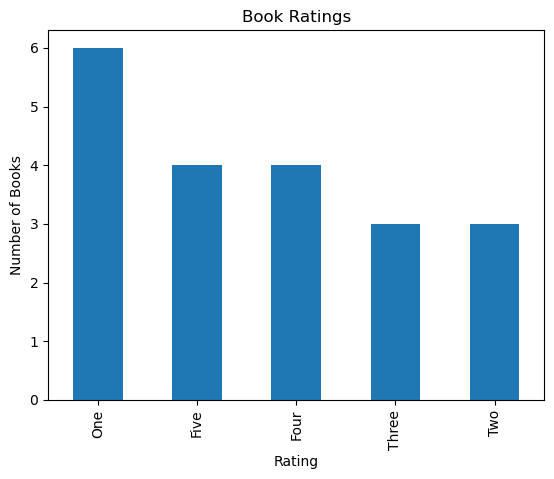

In [12]:
import matplotlib.pyplot as plt

df["Rating"].value_counts().plot(kind="bar")

plt.title("Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()